In [66]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score,
    classification_report, roc_curve, auc, precision_recall_curve,
    average_precision_score, roc_auc_score
)

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelBinarizer, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [69]:
warnings.filterwarnings("ignore")

In [70]:
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
sns.set_palette("husl")

#### Data Loading

In [71]:
train_df = pd.read_csv("dataset/train_genetic_disorders.csv")
test_df  = pd.read_csv("dataset/test_genetic_disorders.csv")

In [72]:
train_df.head(5)

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer


In [73]:
test_df.head(5)

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,History of anomalies in previous pregnancies,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,PID0x4175,6.0,No,Yes,No,No,4.981655,Charles,NaN,Kore,...,-99,2.0,Multiple,-99.000000,slightly abnormal,True,True,True,True,True
1,PID0x21f5,10.0,Yes,No,NaN,Yes,5.118890,Catherine,NaN,Homero,...,Yes,-99.0,Multiple,8.179584,normal,False,False,False,True,False
2,PID0x49b8,5.0,No,NaN,No,No,4.876204,James,NaN,Danield,...,No,0.0,Singular,-99.000000,slightly abnormal,False,False,True,True,False
3,PID0x2d97,13.0,No,Yes,Yes,No,4.687767,Brian,NaN,Orville,...,Yes,-99.0,Singular,6.884071,normal,True,False,True,False,True
4,PID0x58da,5.0,No,NaN,NaN,Yes,5.152362,Gary,NaN,Issiah,...,No,-99.0,Multiple,6.195178,normal,True,True,True,True,False


In [74]:
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape:     {test_df.shape}")
print(f"\nTarget distribution:\n{train_df['Genetic Disorder'].value_counts()}")

Training set shape: (22083, 45)
Test set shape:     (9463, 43)

Target distribution:
Genetic Disorder
Mitochondrial genetic inheritance disorders     9686
Single-gene inheritance diseases                7291
Multifactorial genetic inheritance disorders    1985
Name: count, dtype: int64


#### Data Cleaning

In [75]:
target_col = "Genetic Disorder"
subclass_col = "Disorder Subclass"

In [76]:
drop_cols = [
    "Patient Id",
    "Patient First Name",
    "Family Name",
    "Father's name"
]

In [77]:
y = train_df[target_col].astype(str)
X = train_df.drop(columns=[target_col] + drop_cols, errors="ignore")
test_df = test_df.drop(columns=drop_cols, errors="ignore")

In [78]:
common_cols = X.columns.intersection(test_df.columns)
X = X[common_cols]
test_df = test_df[common_cols]

In [79]:
class_map = {label: idx for idx, label in enumerate(y.unique())}
y_encoded = y.map(class_map)

In [80]:
y_subclass = train_df[subclass_col].astype(str)
subclass_map = {label: idx for idx, label in enumerate(y_subclass.unique())}
y_subclass_encoded = y_subclass.map(subclass_map)

In [81]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

### Preprocessing

In [82]:
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])

In [83]:
categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

In [84]:
preprocessor = ColumnTransformer(
    [("num", numeric_pipeline, num_cols), ("cat", categorical_pipeline, cat_cols)]
)

In [85]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [86]:
y_subclass = train_df["Disorder Subclass"].astype(str)
subclass_map = {label: idx for idx, label in enumerate(y_subclass.unique())}
y_subclass_encoded = y_subclass.map(subclass_map)

In [87]:
_, _, y_sub_train, y_sub_val = train_test_split(
    X,
    y_subclass_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_subclass_encoded
)

In [88]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_val_processed = X_val_processed.toarray()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)

pca_full = PCA().fit(X_train_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumulative_var >= 0.95) + 1

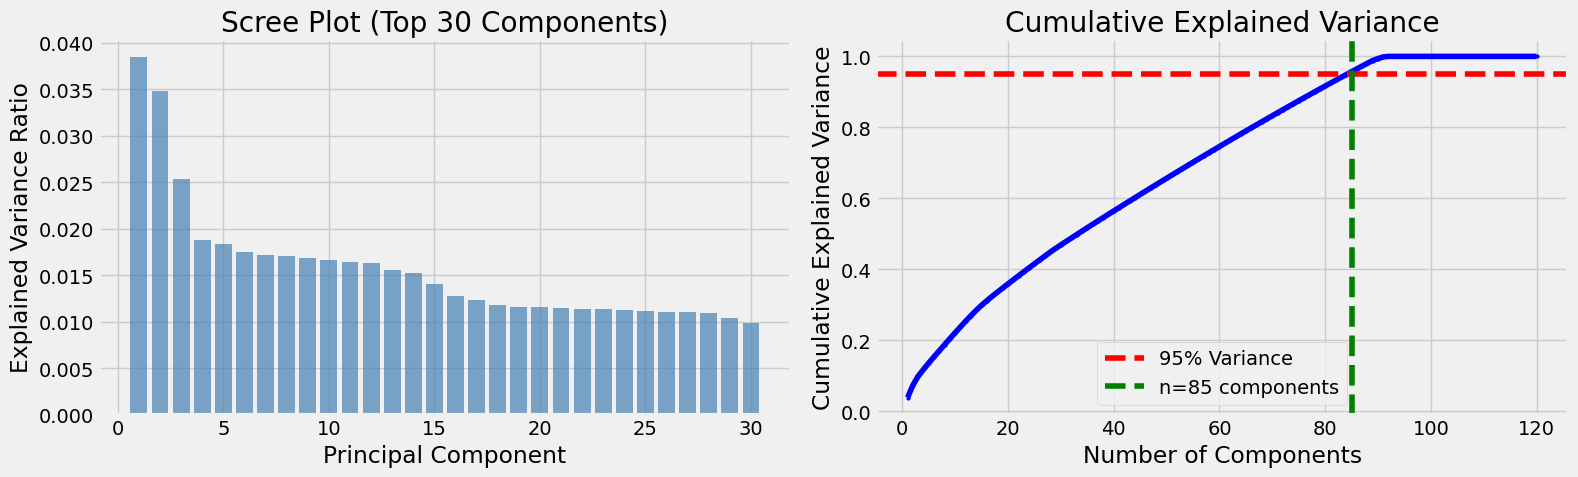


✅ Components needed for 95% variance: 85


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:30], alpha=0.7, color='steelblue')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot (Top 30 Components)")

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'b-o', markersize=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[1].axvline(x=n_95, color='g', linestyle='--', label=f'n={n_95} components')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\n✅ Components needed for 95% variance: {n_95}")

In [90]:
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"Original feature dimensions: {X_train_scaled.shape[1]}")
print(f"PCA reduced dimensions:      {X_train_pca.shape[1]}")
print(f"Variance retained:           {pca.explained_variance_ratio_.sum():.4f}")

Original feature dimensions: 120
PCA reduced dimensions:      85
Variance retained:           0.9569


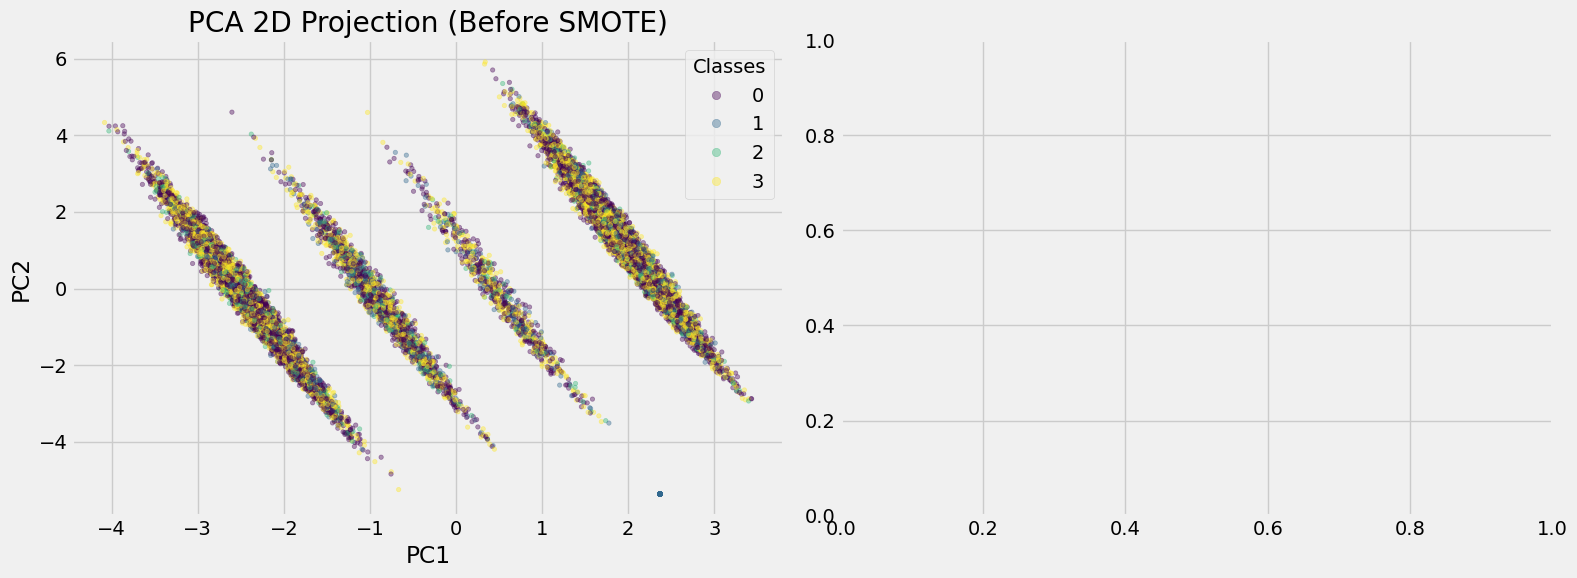

In [91]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before SMOTE
inv_class_map = {v: k for k, v in class_map.items()}
scatter = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_train.values, cmap='viridis', alpha=0.4, s=10)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA 2D Projection (Before SMOTE)")
axes[0].legend(*scatter.legend_elements(), title="Classes", loc="best")

plt.tight_layout()
plt.show()

In [93]:
print("Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

Class distribution BEFORE SMOTE:
Genetic Disorder
0    7748
1    2497
2    1588
3    5833
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Genetic Disorder
0    7748
1    7748
2    7748
3    7748
Name: count, dtype: int64


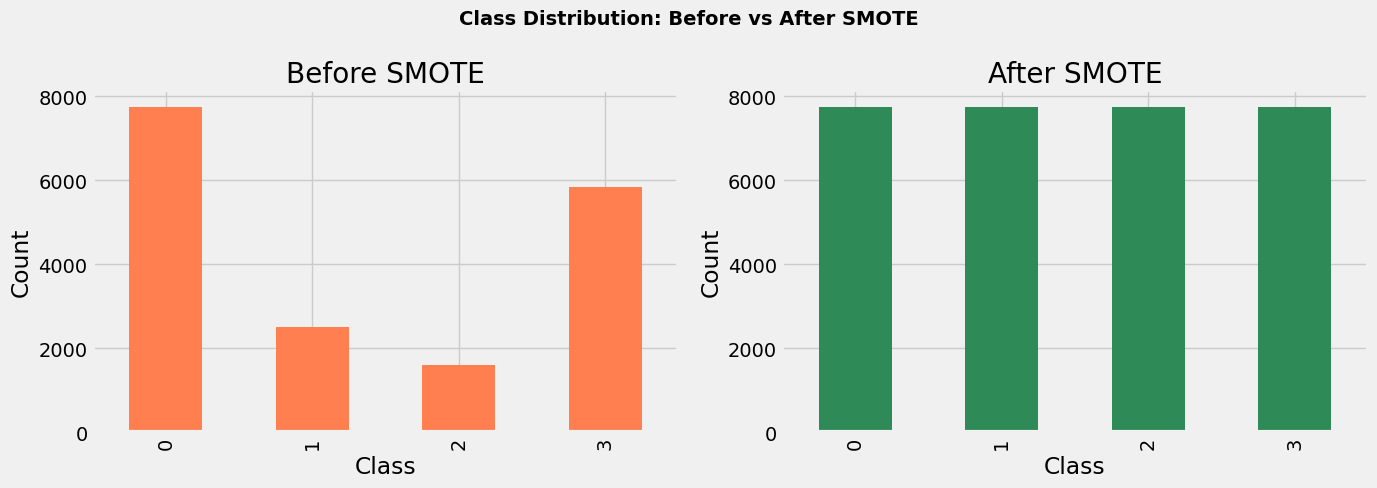

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(y_train).value_counts().sort_index().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

pd.Series(y_train_smote).value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.suptitle("Class Distribution: Before vs After SMOTE", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [97]:
X_train_sub_processed = X_train_pca.copy()
smote_sub = SMOTE(random_state=42)
X_train_smote_sub, y_sub_train_smote = smote_sub.fit_resample(X_train_sub_processed, y_sub_train)

In [98]:
print(f"Subclass distribution AFTER SMOTE:")
print(pd.Series(y_sub_train_smote).value_counts().sort_index())

Subclass distribution AFTER SMOTE:
Disorder Subclass
0    3914
1    3914
2    3914
3    3914
4    3914
5    3914
6    3914
7    3914
8    3914
9    3914
Name: count, dtype: int64


### Models

In [99]:
def plot_feature_importance(model, feature_names, title="Feature Importances", top_n=20):
    """Plot top N feature importances."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(top_n), importances[indices], align='center', color='steelblue')
    plt.xticks(range(top_n), [feature_names[i] if i < len(feature_names) else f"PC{i}" for i in indices], rotation=90)
    plt.title(f"Top {top_n} {title}")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

In [100]:
def plot_confusion(y_true, y_pred, title):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

In [102]:
def plot_classification_report_heatmap(y_true, y_pred, title="Classification Report"):
    """Plot classification report as a heatmap."""
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T
    
    # Filter out support and averages for cleaner view
    metrics_cols = ['precision', 'recall', 'f1-score']
    report_df = report_df[metrics_cols]
    
    plt.figure(figsize=(10, max(4, len(report_df) * 0.4)))
    sns.heatmap(report_df, annot=True, cmap='YlOrRd', fmt='.3f', linewidths=0.5)
    plt.title(title)
    plt.ylabel("Class / Average")
    plt.xlabel("Metric")
    plt.tight_layout()
    plt.show()

In [103]:
def plot_roc_curves(y_true, y_pred_proba, class_names, title="ROC Curves"):
    """Plot one-vs-rest ROC curves for multiclass classification."""
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))
    
    for i, (color, name) in enumerate(zip(colors, class_names)):
        if y_pred_proba.shape[1] > i:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

In [104]:
def plot_precision_recall_curves(y_true, y_pred_proba, class_names, title="Precision-Recall Curves"):
    """Plot precision-recall curves for multiclass."""
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = plt.cm.Set2(np.linspace(0, 1, n_classes))
    
    for i, (color, name) in enumerate(zip(colors, class_names)):
        if y_pred_proba.shape[1] > i:
            precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_proba[:, i])
            ap = average_precision_score(y_true_bin[:, i], y_pred_proba[:, i])
            ax.plot(recall, precision, color=color, lw=2, label=f'{name} (AP = {ap:.3f})')
    
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title)
    ax.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.show()

In [105]:
def full_model_evaluation(model_name, y_true, y_pred, y_pred_proba=None, class_names=None):
    """Run all evaluation plots for a model."""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"  Accuracy: {acc:.4f} | F1 Score (weighted): {f1:.4f}")
    print(f"{'='*60}")
    print(f"\n{classification_report(y_true, y_pred, zero_division=0)}")
    
    # Confusion Matrix
    plot_confusion(y_true, y_pred, f"{model_name} — Confusion Matrix")
    
    # Classification Report Heatmap
    plot_classification_report_heatmap(y_true, y_pred, f"{model_name} — Classification Report")
    
    # ROC & PR curves (if probabilities available)
    if y_pred_proba is not None and class_names is not None:
        plot_roc_curves(y_true, y_pred_proba, class_names, f"{model_name} — ROC Curves (One-vs-Rest)")
        plot_precision_recall_curves(y_true, y_pred_proba, class_names, f"{model_name} — Precision-Recall Curves")
    
    return acc, f1

In [ ]:
pca_feature_names = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
class_names = [inv_class_map[i] for i in sorted(inv_class_map.keys())]
print(f"Classes: {class_names}")

Classes: ['Mitochondrial genetic inheritance disorders', 'nan', 'Multifactorial genetic inheritance disorders', 'Single-gene inheritance diseases']


In [110]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1
)

In [112]:
rf_model.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric


  Random Forest
  Accuracy: 0.4831 | F1 Score (weighted): 0.4702

              precision    recall  f1-score   support

           0       0.52      0.70      0.59      1938
           1       0.92      0.30      0.46       624
           2       0.28      0.36      0.32       397
           3       0.41      0.31      0.35      1458

    accuracy                           0.48      4417
   macro avg       0.53      0.42      0.43      4417
weighted avg       0.52      0.48      0.47      4417



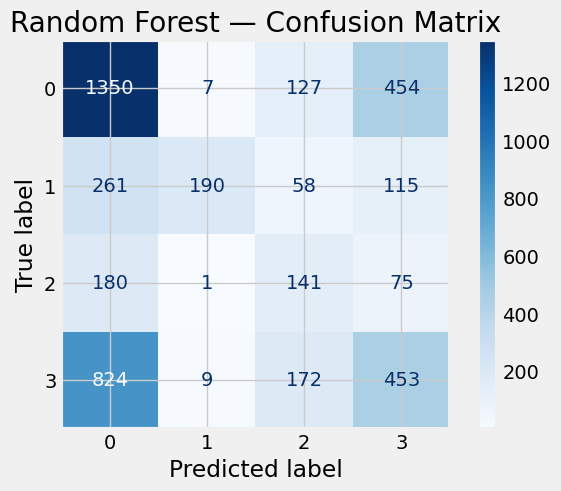

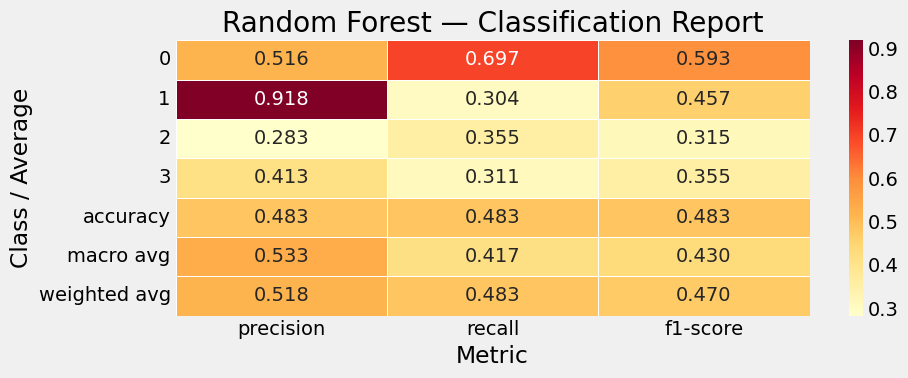

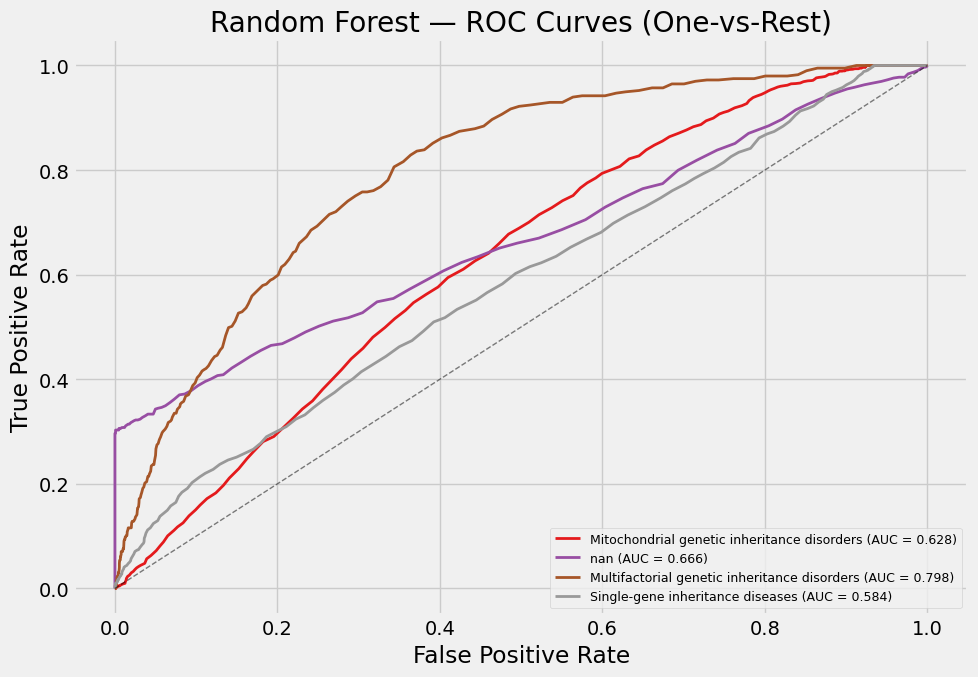

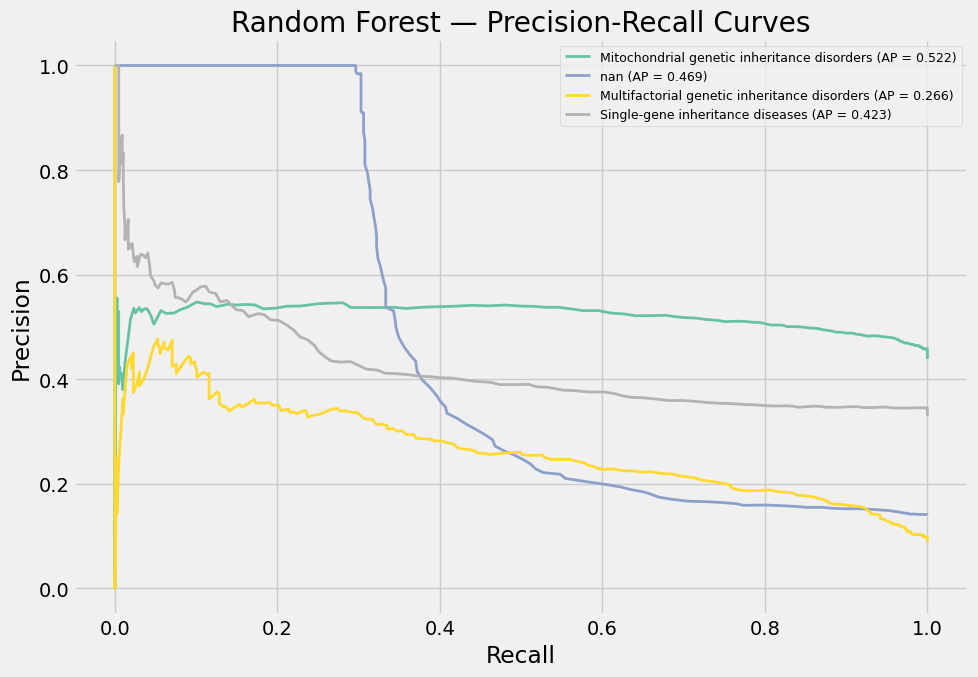

In [115]:
rf_val_pred_classes = rf_model.predict(X_val_pca)
rf_val_pred_proba = rf_model.predict_proba(X_val_pca)

rf_acc, rf_f1 = full_model_evaluation("Random Forest", y_val, rf_val_pred_classes, rf_val_pred_proba, class_names)

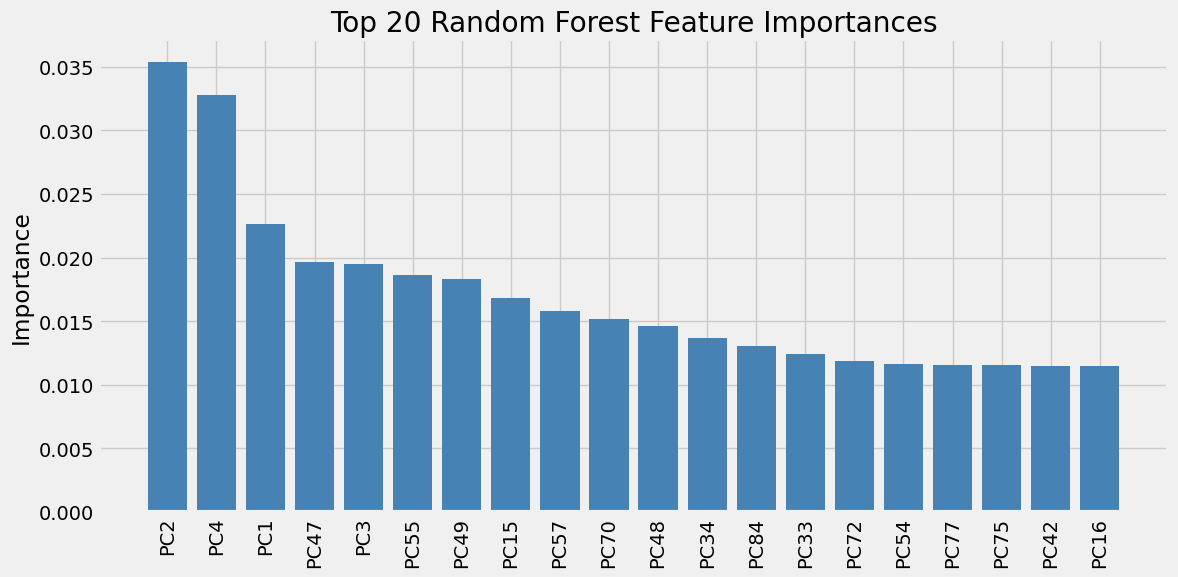

In [116]:
plot_feature_importance(rf_model, pca_feature_names, title="Random Forest Feature Importances", top_n=min(20, len(pca_feature_names)))

#### 🚀 XGBoost

In [118]:
xgb_model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

In [119]:
xgb_model.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr


  XGBoost
  Accuracy: 0.4632 | F1 Score (weighted): 0.4544

              precision    recall  f1-score   support

           0       0.50      0.64      0.56      1938
           1       0.72      0.32      0.44       624
           2       0.31      0.36      0.33       397
           3       0.38      0.32      0.35      1458

    accuracy                           0.46      4417
   macro avg       0.48      0.41      0.42      4417
weighted avg       0.48      0.46      0.45      4417



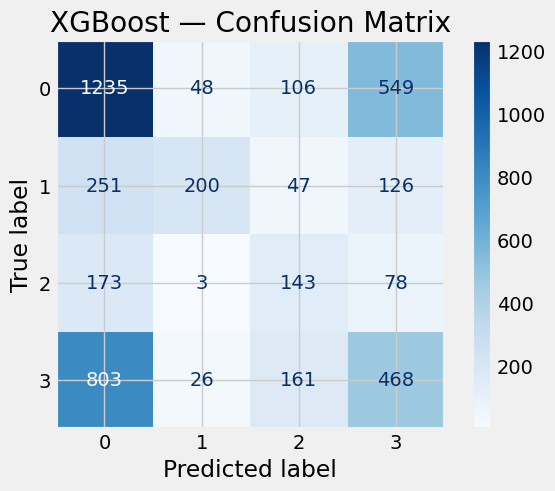

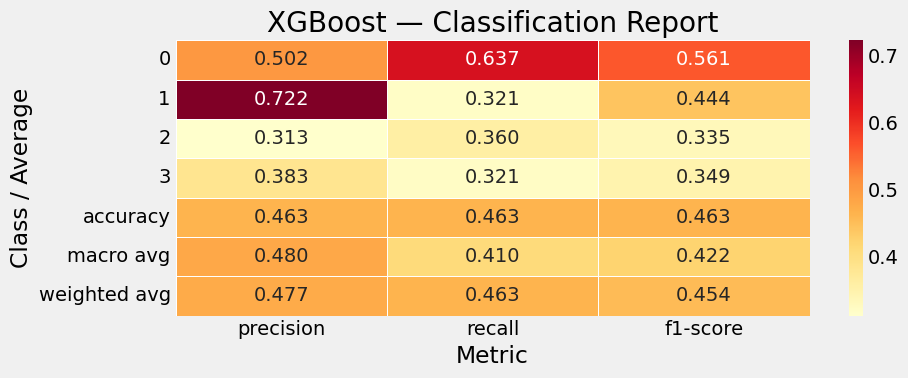

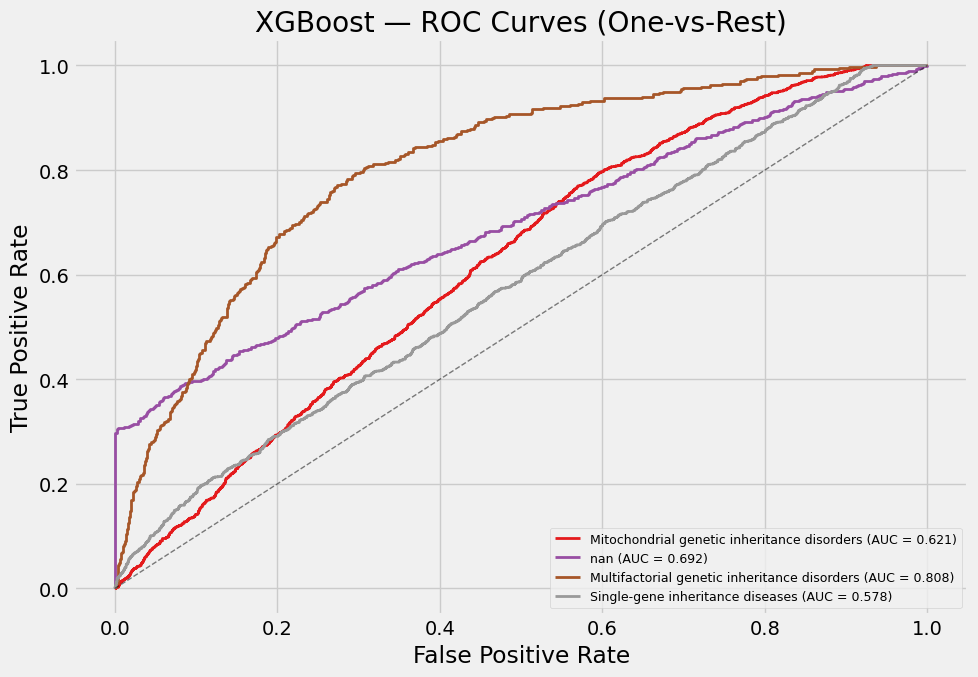

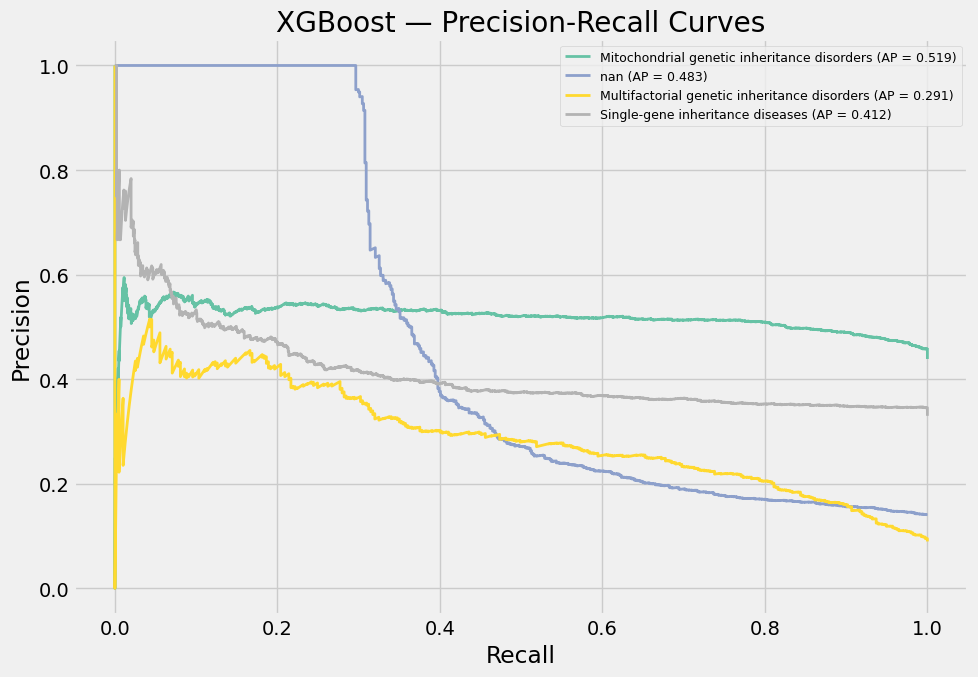

In [120]:
xgb_val_pred_classes = xgb_model.predict(X_val_pca)
xgb_val_pred_proba = xgb_model.predict_proba(X_val_pca)

xgb_acc, xgb_f1 = full_model_evaluation(
    "XGBoost", y_val, xgb_val_pred_classes, xgb_val_pred_proba, class_names
)

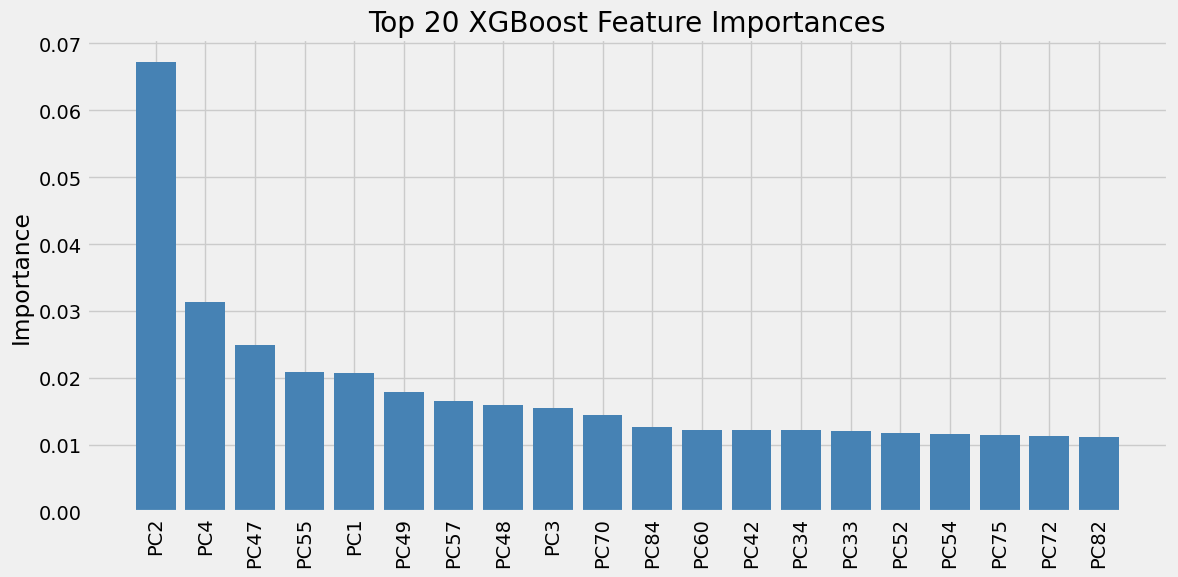

In [121]:
plot_feature_importance(xgb_model, pca_feature_names, title="XGBoost Feature Importances", top_n=min(20, len(pca_feature_names)))

#### 🎯 Support Vector Machine

In [122]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=25,
    probability=True
)

In [123]:
svm_model.fit(X_train_smote, y_train_smote)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False



  SVM
  Accuracy: 0.4675 | F1 Score (weighted): 0.4604

              precision    recall  f1-score   support

           0       0.51      0.62      0.56      1938
           1       0.61      0.34      0.44       624
           2       0.33      0.40      0.36       397
           3       0.39      0.33      0.36      1458

    accuracy                           0.47      4417
   macro avg       0.46      0.42      0.43      4417
weighted avg       0.47      0.47      0.46      4417



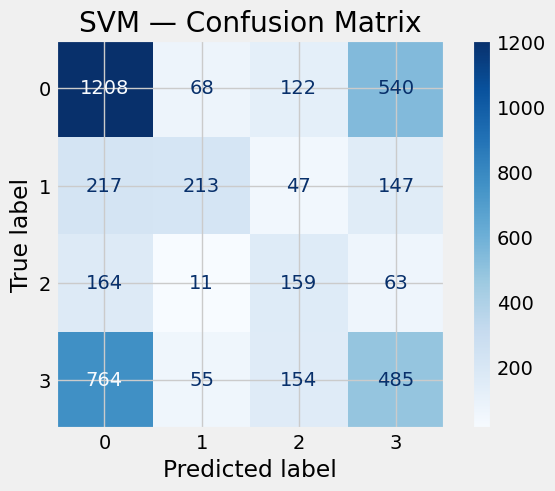

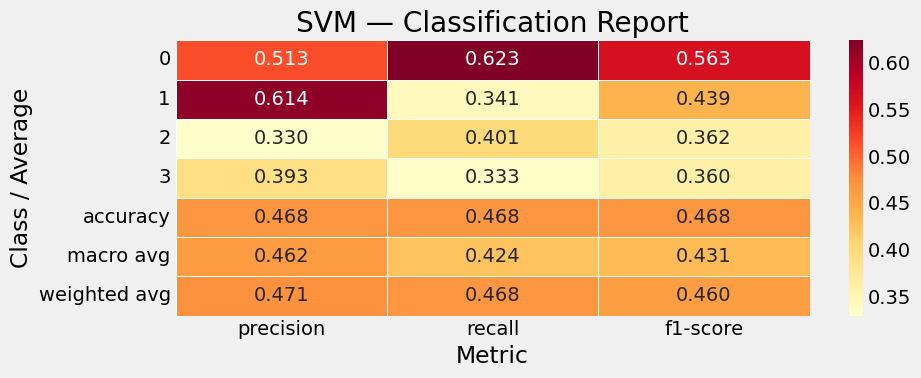

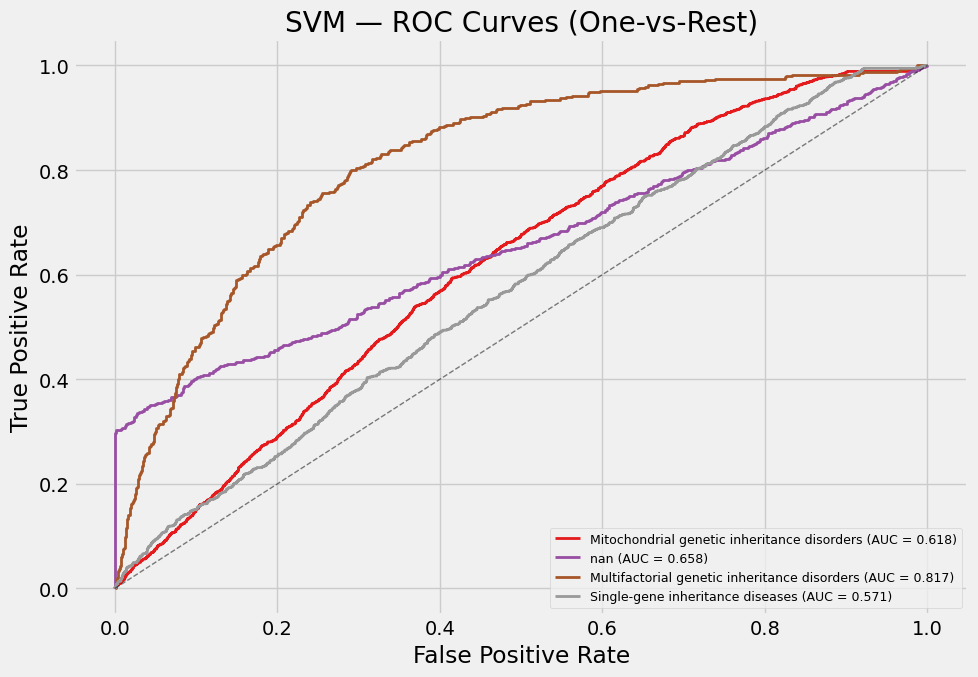

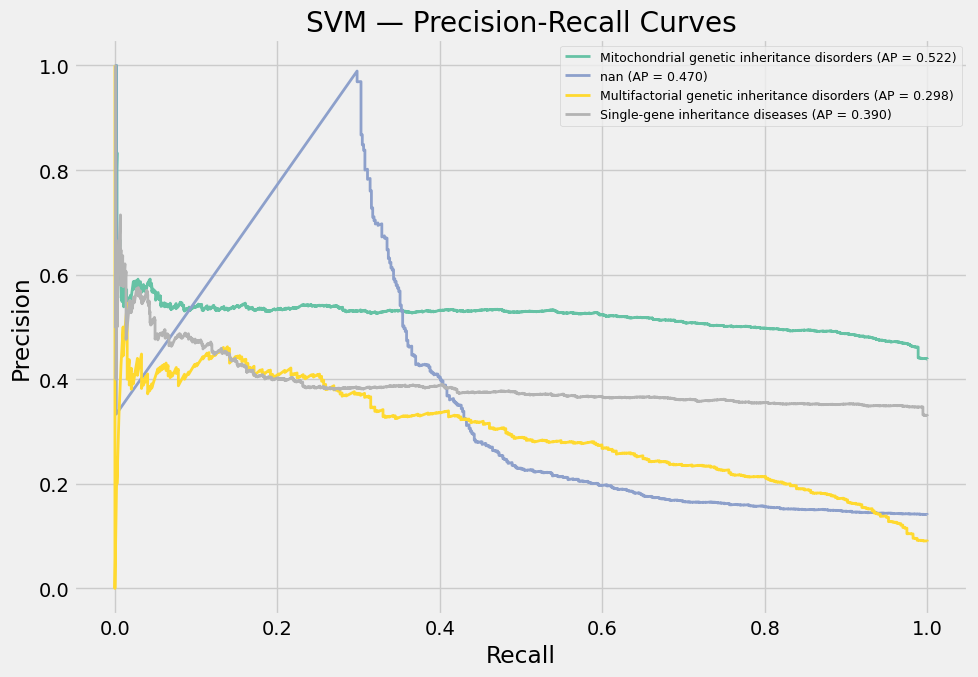

In [124]:
svm_val_pred_classes = svm_model.predict(X_val_pca)
svm_val_pred_proba = svm_model.predict_proba(X_val_pca)

svm_acc, svm_f1 = full_model_evaluation(
    "SVM", y_val, svm_val_pred_classes, svm_val_pred_proba, class_names
)

### 🧠 Neural Network (Stacking Ensemble)

In [125]:
rf_train_pred = rf_model.predict_proba(X_train_smote)
xgb_train_pred = xgb_model.predict_proba(X_train_smote)
svm_train_pred = svm_model.predict_proba(X_train_smote)

In [126]:
rf_val_pred = rf_model.predict_proba(X_val_pca)
xgb_val_pred = xgb_model.predict_proba(X_val_pca)
svm_val_pred = svm_model.predict_proba(X_val_pca)

In [127]:
stacked_train = np.hstack([rf_train_pred, xgb_train_pred, svm_train_pred])
stacked_val = np.hstack([rf_val_pred, xgb_val_pred, svm_val_pred])

In [128]:
X_train_nn = torch.tensor(stacked_train, dtype=torch.float32)
X_val_nn = torch.tensor(stacked_val, dtype=torch.float32)

y_train_nn = torch.tensor(y_train_smote.to_numpy() if hasattr(y_train_smote, 'to_numpy') else np.array(y_train_smote), dtype=torch.long)
y_val_nn = torch.tensor(y_val.to_numpy(), dtype=torch.long)

In [129]:
class GeneticDisorderNN(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_classes=len(class_names)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size // 2, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

In [130]:
model = GeneticDisorderNN(input_size=X_train_nn.shape[1])

In [131]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

In [132]:
epochs = 150
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_nn)
    loss = criterion(outputs, y_train_nn)
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    train_losses.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_nn)
        val_loss = criterion(val_outputs, y_val_nn)
        val_losses.append(val_loss.item())
    
    if epoch % 15 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

Epoch 000 | Train Loss: 1.3531 | Val Loss: 1.3655
Epoch 015 | Train Loss: 0.0489 | Val Loss: 1.1698
Epoch 030 | Train Loss: 0.0039 | Val Loss: 1.4241
Epoch 045 | Train Loss: 0.0024 | Val Loss: 1.6639
Epoch 060 | Train Loss: 0.0019 | Val Loss: 1.7525
Epoch 075 | Train Loss: 0.0020 | Val Loss: 1.7892
Epoch 090 | Train Loss: 0.0019 | Val Loss: 1.8045
Epoch 105 | Train Loss: 0.0018 | Val Loss: 1.8154
Epoch 120 | Train Loss: 0.0017 | Val Loss: 1.8216
Epoch 135 | Train Loss: 0.0015 | Val Loss: 1.8265


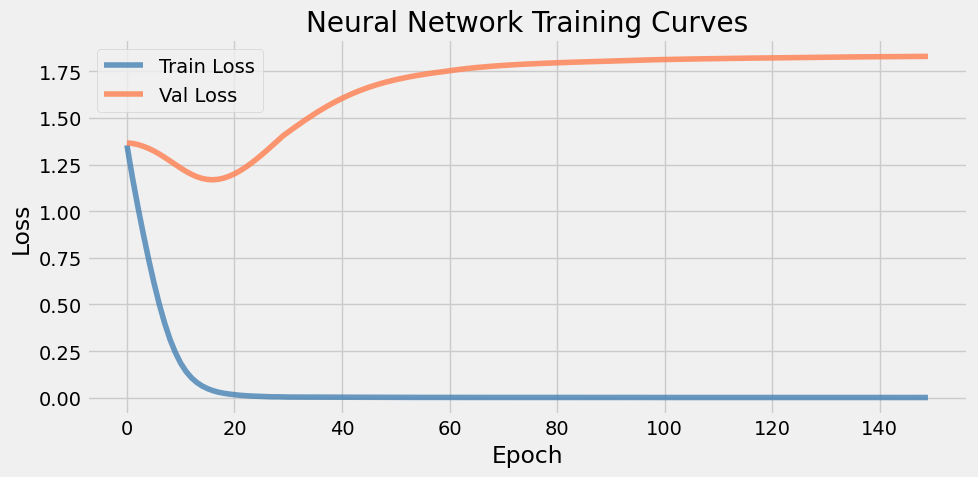

In [133]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', color='steelblue', alpha=0.8)
ax.plot(val_losses, label='Val Loss', color='coral', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Neural Network Training Curves')
ax.legend()
plt.tight_layout()
plt.show()


  Neural Network (Stacking)
  Accuracy: 0.4908 | F1 Score (weighted): 0.4668

              precision    recall  f1-score   support

           0       0.51      0.75      0.61      1938
           1       0.80      0.31      0.45       624
           2       0.33      0.33      0.33       397
           3       0.42      0.26      0.33      1458

    accuracy                           0.49      4417
   macro avg       0.52      0.41      0.43      4417
weighted avg       0.51      0.49      0.47      4417



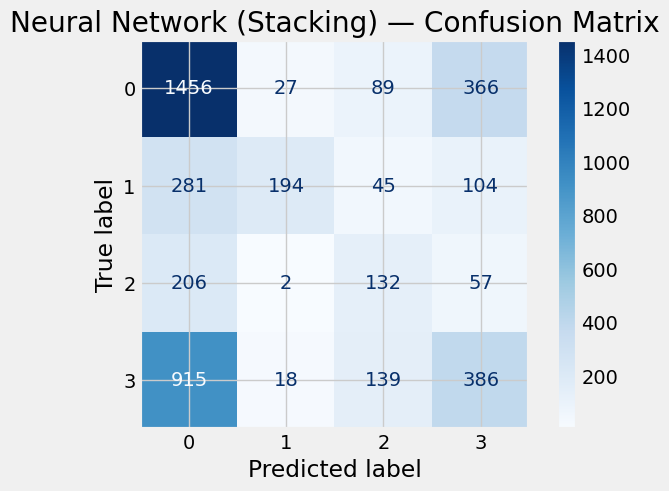

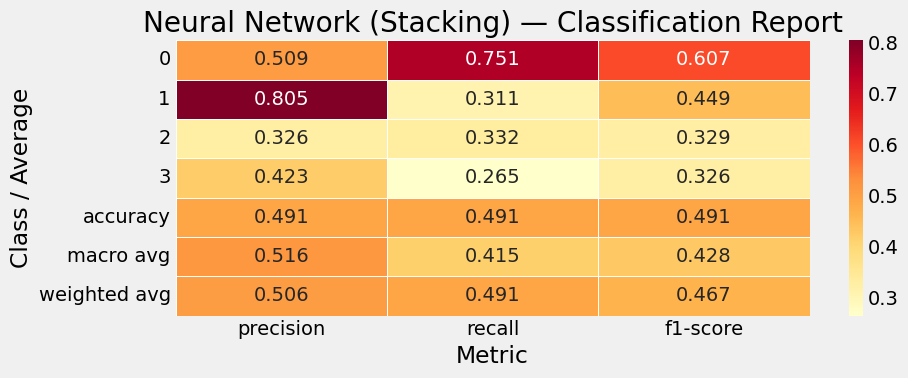

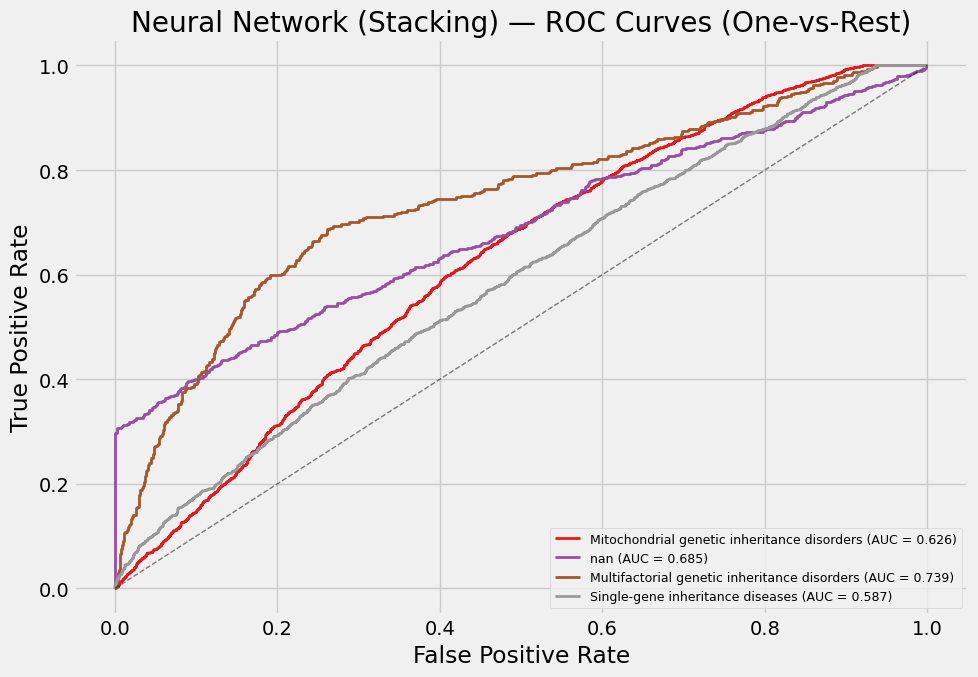

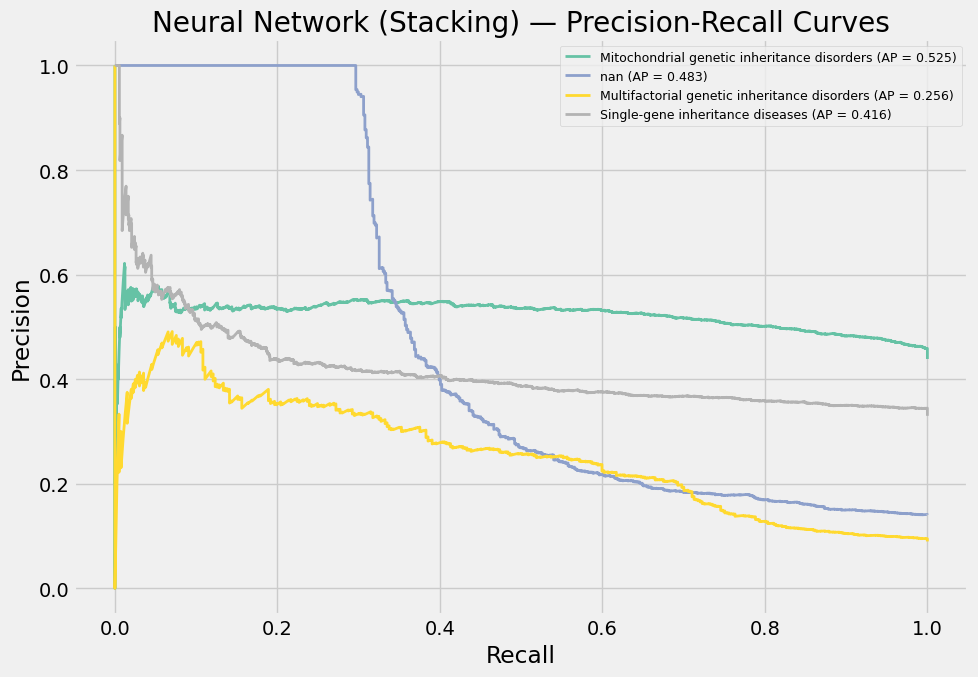

In [134]:
model.eval()

with torch.no_grad():
    nn_val_logits = model(X_val_nn)
    nn_val_pred_proba = torch.softmax(nn_val_logits, dim=1).numpy()
    nn_val_pred_classes = torch.argmax(nn_val_logits, dim=1).numpy()

nn_acc, nn_f1 = full_model_evaluation(
    "Neural Network (Stacking)", y_val, nn_val_pred_classes, nn_val_pred_proba, class_names
)

### 🔄 Cross-Validation
Stratified K-Fold cross-validation to get robust performance estimates for each model.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_weighted']

cv_results = {}

print("Running 5-Fold CV for Random Forest...")

rf_cv = cross_validate(
    RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42, max_features="sqrt", n_jobs=-1),
    X_train_smote, y_train_smote, cv=cv, scoring=scoring, return_train_score=True
)

cv_results['Random Forest'] = rf_cv

print(f"Accuracy: {rf_cv['test_accuracy'].mean():.4f} ± {rf_cv['test_accuracy'].std():.4f}")
print(f"F1:       {rf_cv['test_f1_weighted'].mean():.4f} ± {rf_cv['test_f1_weighted'].std():.4f}")


print("\nRunning 5-Fold CV for XGBoost...")

xgb_cv = cross_validate(
    XGBClassifier(n_estimators=600, learning_rate=0.03, max_depth=8, subsample=0.8, random_state=42, eval_metric="mlogloss", n_jobs=-1),
    X_train_smote, y_train_smote, cv=cv, scoring=scoring, return_train_score=True
)

cv_results['XGBoost'] = xgb_cv

print(f"Accuracy: {xgb_cv['test_accuracy'].mean():.4f} ± {xgb_cv['test_accuracy'].std():.4f}")
print(f"F1:       {xgb_cv['test_f1_weighted'].mean():.4f} ± {xgb_cv['test_f1_weighted'].std():.4f}")


print("\nRunning 5-Fold CV for SVM...")

svm_cv = cross_validate(
    SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=25),
    X_train_smote, y_train_smote, cv=cv, scoring=scoring, return_train_score=True
)

cv_results['SVM'] = svm_cv

print(f"Accuracy: {svm_cv['test_accuracy'].mean():.4f} ± {svm_cv['test_accuracy'].std():.4f}")
print(f"F1:       {svm_cv['test_f1_weighted'].mean():.4f} ± {svm_cv['test_f1_weighted'].std():.4f}")

Running 5-Fold CV for Random Forest...
  Accuracy: 0.7477 ± 0.0044
  F1:       0.7476 ± 0.0049

Running 5-Fold CV for XGBoost...
  Accuracy: 0.7380 ± 0.0041
  F1:       0.7368 ± 0.0039

Running 5-Fold CV for SVM...


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
acc_data = [cv_results[m]['test_accuracy'] for m in cv_results]
bp1 = axes[0].boxplot(acc_data, labels=list(cv_results.keys()), patch_artist=True)
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']

for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title("5-Fold CV: Accuracy Distribution")
axes[0].set_ylabel("Accuracy")

f1_data = [cv_results[m]['test_f1_weighted'] for m in cv_results]
bp2 = axes[1].boxplot(f1_data, labels=list(cv_results.keys()), patch_artist=True)

for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    
axes[1].set_title("5-Fold CV: F1 Score Distribution")
axes[1].set_ylabel("F1 Score (weighted)")

plt.suptitle("Cross-Validation Results Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Model Comparison Dashboard

In [ ]:
# Summary comparison
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'SVM', 'NN (Stacking)'],
    'Val Accuracy': [rf_acc, xgb_acc, svm_acc, nn_acc],
    'Val F1 (weighted)': [rf_f1, xgb_f1, svm_f1, nn_f1],
    'CV Accuracy (mean)': [
        rf_cv['test_accuracy'].mean(),
        xgb_cv['test_accuracy'].mean(),
        svm_cv['test_accuracy'].mean(),
        np.nan  # NN doesn't have standard CV
    ],
    'CV F1 (mean)': [
        rf_cv['test_f1_weighted'].mean(),
        xgb_cv['test_f1_weighted'].mean(),
        svm_cv['test_f1_weighted'].mean(),
        np.nan
    ]
})

print(results_df.to_string(index=False))

In [ ]:
# Visual comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['Model']
x = np.arange(len(models))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, results_df['Val Accuracy'], width, label='Validation', color='steelblue', alpha=0.8)
cv_acc = results_df['CV Accuracy (mean)'].fillna(0)
axes[0].bar(x + width/2, cv_acc, width, label='CV Mean', color='coral', alpha=0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: Validation vs Cross-Validation')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 1)

# F1 comparison
axes[1].bar(x - width/2, results_df['Val F1 (weighted)'], width, label='Validation', color='steelblue', alpha=0.8)
cv_f1 = results_df['CV F1 (mean)'].fillna(0)
axes[1].bar(x + width/2, cv_f1, width, label='CV Mean', color='coral', alpha=0.8)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score: Validation vs Cross-Validation')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap of all results
fig, ax = plt.subplots(figsize=(10, 4))
heatmap_data = results_df.set_index('Model')[['Val Accuracy', 'Val F1 (weighted)', 'CV Accuracy (mean)', 'CV F1 (mean)']]
sns.heatmap(heatmap_data, annot=True, cmap='YlGn', fmt='.4f', linewidths=1, ax=ax, vmin=0, vmax=1)
ax.set_title("Model Performance Heatmap")
plt.tight_layout()
plt.show()

print("\n🏆 Best model by validation accuracy:", results_df.loc[results_df['Val Accuracy'].idxmax(), 'Model'])
print("🏆 Best model by CV accuracy:", results_df.loc[results_df['CV Accuracy (mean)'].idxmax(), 'Model'])

### 💾 Save Models & Artifacts
The trained models, preprocessor, scaler, and PCA transformer are available for the MLflow integration script (`mlflow_integration.py`).

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(pca, "models/pca.pkl")
joblib.dump(rf_model, "models/rf_model.pkl")
joblib.dump(xgb_model, "models/xgb_model.pkl")
joblib.dump(svm_model, "models/svm_model.pkl")
torch.save(model.state_dict(), "models/nn_stacking_model.pt")

# Save metadata
metadata = {
    "class_map": class_map,
    "inv_class_map": {str(k): v for k, v in inv_class_map.items()},
    "pca_n_components": int(n_95),
    "pca_variance_retained": float(pca.explained_variance_ratio_.sum()),
    "results": results_df.to_dict(),
}

import json
with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("✅ All models and artifacts saved to ./models/")